In [ ]:
# Handling Missing Value:

# There are 2 way to handle missing value
    # 1. Remove them
        # Complete Case Analysis
    # 2. Impuete the missing value (Fill)
        # Univariate:
            # Numerical Data: Mean, Random Value, End of Distribution (Simple Imputer)
            # Categorical Data: Most frequent value, Write Missing (Simple Imputer)
        # Multivariate
            # KNN Imputer   
            # Iterative Imputer (MICE)

In [ ]:
                # -----------Complete Case Analysis------------#
# Also Called 'list wise deletion' of cases, consists in discarding observation(row) where values in any of the variables are missing.

# when use CCA:
    #1. Missing data is very small (5%)
    #2. Data is Missing Completely At Random (MCAR)
    #3. You have a large dataset

In [3]:
# Example of CCA

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Import Dataset
Data=pd.read_csv('data_science_job.csv')

In [5]:
# Check tha dataset
Data.head(3)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0


In [7]:
# Shape of the dataset
Data.shape

(19158, 13)

In [6]:
# Calculate the null value at each column
Data.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [ ]:
# Here, the percentage of null value in some column is less than 5%
# So we can perform CCA on some column

In [ ]:
# Extract columns that have missing value less than 5%
cols=[var for var in Data.columns 
      if Data[var].isnull().mean() <0.05 and Data[var].isnull().mean()>0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [10]:
# show the dataset
Data[cols].head(3)

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0


In [ ]:
# Percentage of row after dropna
len(Data[cols].dropna())/len(Data)

0.8968577095730244

In [14]:
# Now drop None value
New_data=Data[cols].dropna()
Data.shape, New_data.shape

((19158, 13), (17182, 5))

<Figure size 400x400 with 0 Axes>

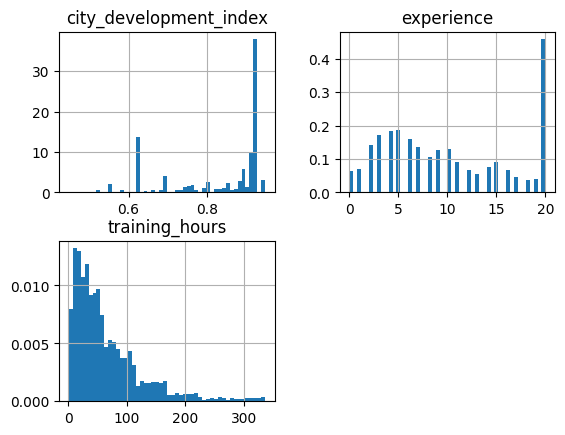

In [16]:
# Draw bar plot
plt.figure(figsize=(4,4))
New_data.hist(bins=50, density=True)
plt.show()

<Axes: >

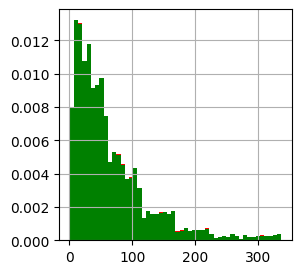

In [ ]:
# Compare training_hours 
plt.figure(figsize=(3,3))
Data['training_hours'].hist(bins=50, density=True, color='red')
New_data['training_hours'].hist(bins=50, density=True, color='green')

<Axes: >

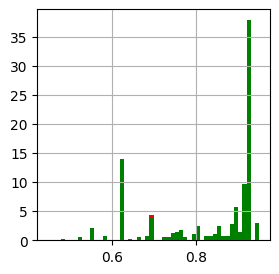

In [18]:
# Compare city_development_index
plt.figure(figsize=(3,3))
Data['city_development_index'].hist(bins=50, density=True, color='red')
New_data['city_development_index'].hist(bins=50, density=True, color='green')

In [ ]:
# Here, in both case distribution is overlaped

<Axes: ylabel='Density'>

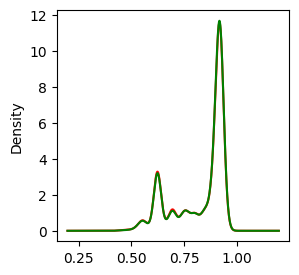

In [19]:
plt.figure(figsize=(3,3))
Data['city_development_index'].plot.density(color='red')
New_data['city_development_index'].plot.density(color='green')

In [ ]:
# Distribution in booth case is same

<Axes: >

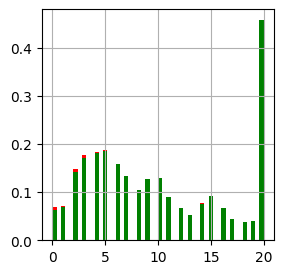

In [21]:
# Compare experiance
plt.figure(figsize=(3,3))
Data['experience'].hist(bins=50, density=True, color='red')
New_data['experience'].hist(bins=50, density=True, color='green')

In [ ]:
# Distribution in booth case is same

In [ ]:
# Compare categorical column
temp=pd.concat([
    # percentage of observation per category, original data
    Data['enrolled_university'].value_counts()/len(Data),
    # percentage of observation per category, CCA
    New_data['enrolled_university'].value_counts()/len(Data),
],axis=1
)
temp.columns=['original', 'CCA']
temp

,original,CCA
enrolled_university,,
no_enrollment,0.721213,0.659359
Full time course,0.196106,0.180029
Part time course,0.062533,0.057469


In [24]:
temp=pd.concat([
    # percentage of observation per category, original data
    Data['education_level'].value_counts()/len(Data),
    # percentage of observation per category, CCA
    New_data['education_level'].value_counts()/len(Data),
],axis=1
)
temp.columns=['original', 'CCA']
temp

,original,CCA
education_level,,
Graduate,0.605387,0.555904
Masters,0.227633,0.209938
High School,0.105282,0.096304
Phd,0.021610,0.019835
Primary School,0.016077,0.014876
